# Optimized Heart Failure Prediction

This notebook builds a highly optimized heart failure prediction model using the `heart.csv` dataset. It utilizes `StandardScaler` for feature scaling, `SMOTE` to balance the dataset, and a hyperparameter-tuned `RandomForestClassifier`. The visualizations focus exclusively on the SMOTE distribution differences, the Confusion Matrix, and the model's Learning Curve.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Data Preprocessing & Scaling
We encode categorical variables and scale numerical variables. Scaling is critical here because SMOTE relies on distance metrics to generate synthetic data.

In [7]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Perform One-Hot Encoding
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

### 2. Apply SMOTE and Visualize Class Distribution
With our features scaled, we can safely generate synthetic data to balance our minority class.

/var/folders/5q/447__pb118b8npdnb1ryrzl40000gn/T/ipykernel_24761/2883912436.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=ax[0], palette='Set2')
/var/folders/5q/447__pb118b8npdnb1ryrzl40000gn/T/ipykernel_24761/2883912436.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=ax[1], palette='Set2')


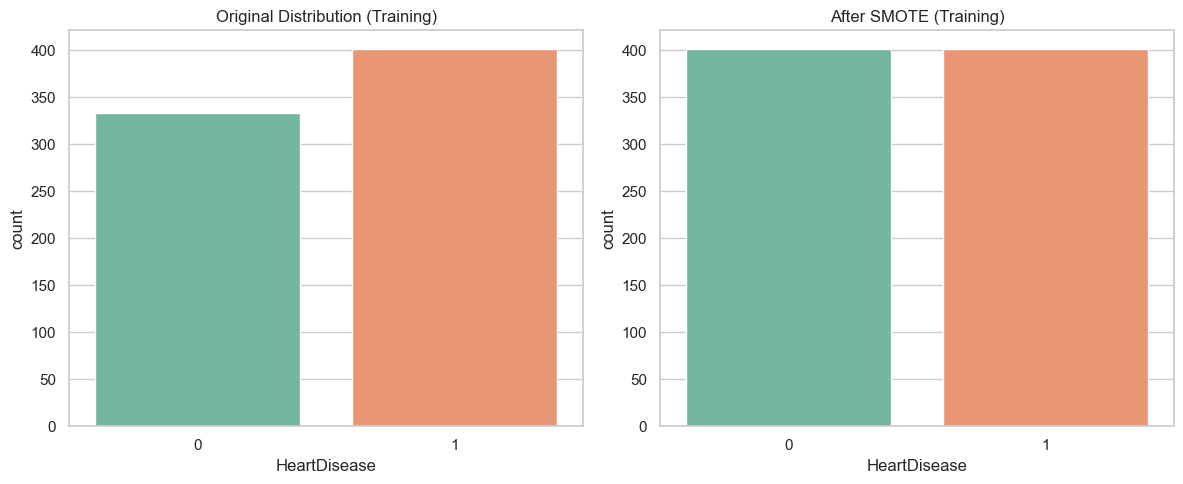

In [8]:
# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- VISUALIZATION 1: SMOTE DIFFERENCE ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=ax[0], palette='Set2')
ax[0].set_title('Original Distribution (Training)')

sns.countplot(x=y_train_smote, ax=ax[1], palette='Set2')
ax[1].set_title('After SMOTE (Training)')

plt.tight_layout()
plt.show()

### 3. Train Optimized Random Forest
We use `GridSearchCV` to test multiple hyperparameter combinations and find the best fit for our balanced data.

In [9]:
# Initialize Random Forest with balanced class weights
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Tuning model hyperparameters... This may take a moment.")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

best_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

# Make predictions for evaluation
y_pred = best_model.predict(X_test)

Tuning model hyperparameters... This may take a moment.
Best Parameters Found: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### 4. Evaluation and Visualizations
Displaying the Confusion Matrix and Learning Curve for the optimized model.

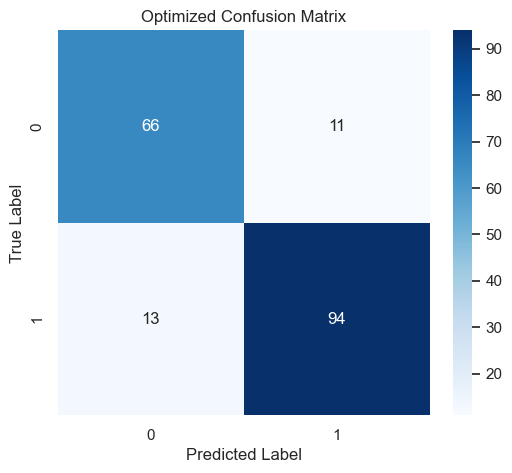

In [10]:
# --- VISUALIZATION 2: CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

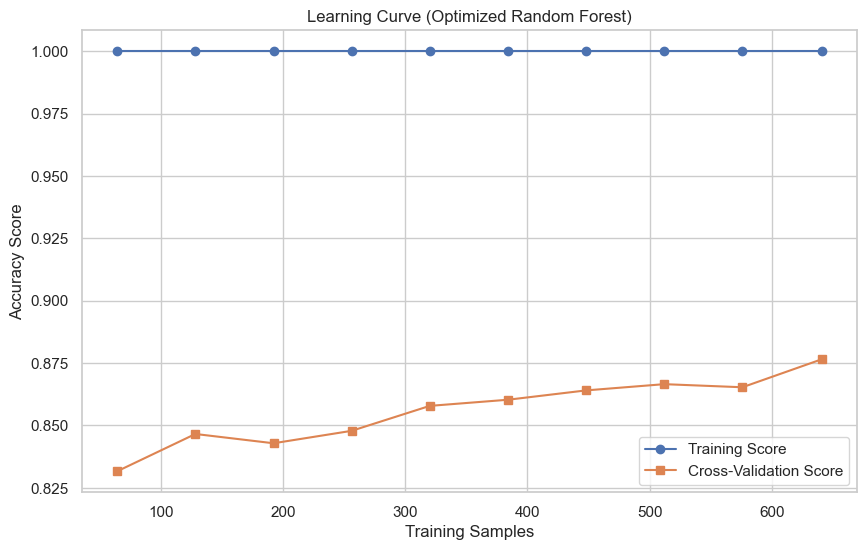

Optimized Model Accuracy: 0.8696

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [11]:
# --- VISUALIZATION 3: LEARNING CURVE ---
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_smote, y_train_smote, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', marker='s')
plt.title('Learning Curve (Optimized Random Forest)')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Final Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Optimized Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))